# HCC1806: Feature selection + classifiers (DropSeq)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import pickle
import os

os.makedirs('../outputs/models', exist_ok=True)
os.makedirs('../outputs/figures', exist_ok=True)

## 1. Load data

In [4]:
train_raw = pd.read_csv('../data/DropSeq/HCC1806_Filtered_Normalised_3000_Data_train.txt',
                        sep=' ', index_col=0)
test_raw  = pd.read_csv('../data/DropSeq/HCC1806_Filtered_Normalised_3000_Data_test_anonim.txt',
                        sep=' ', index_col=0)

train_raw = train_raw.T
test_raw  = test_raw.T

print('Train shape (cells x genes):', train_raw.shape)
print('Test shape (cells x genes):', test_raw.shape)
print('Train sample cell names:', train_raw.index[:3].tolist())
print('Test sample cell names:', test_raw.index[:3].tolist())

Train shape (cells x genes): (14682, 3000)
Test shape (cells x genes): (3671, 3000)
Train sample cell names: ['AAAAAACCCGGC_Normoxia', 'AAAACCGGATGC_Normoxia', 'AAAACGAGCTAG_Normoxia']
Test sample cell names: ['1', '2', '3']


## 2. Extract labels

In [7]:
y_train = train_raw.index.str.split('_').str[-1].values

x_train = train_raw.values
x_test  = test_raw.values

print('Train label distribution:', pd.Series(y_train).value_counts().to_dict())
print('Test cells (no labels):', x_test.shape[0])

Train label distribution: {'Hypoxia': 8899, 'Normoxia': 5783}
Test cells (no labels): 3671


## 3. Feature selection

In [8]:
var_filter = VarianceThreshold(threshold=0.01)
x_train_var = var_filter.fit_transform(x_train)
x_test_var  = var_filter.transform(x_test)

print(f'Genes before variance filter: {x_train.shape[1]}')
print(f'Genes after variance filter: {x_train_var.shape[1]}')

Genes before variance filter: 3000
Genes after variance filter: 1113


In [9]:
N_TOP_GENES = 500

mi_scores = mutual_info_classif(x_train_var, y_train, random_state=42)
top_idx   = np.argsort(mi_scores)[::-1][:N_TOP_GENES]

x_train_top = x_train_var[:, top_idx]
x_test_top  = x_test_var[:, top_idx]

print(f'Genes after mutual information selection: {x_train_top.shape[1]}')

genes_after_var = train_raw.columns[var_filter.get_support()]
top_genes = genes_after_var[top_idx]
pd.Series(mi_scores[top_idx], index=top_genes).sort_values(ascending=False).to_csv('../outputs/HCC1806_top_genes.csv', header=['mi_score'])

print('Saved: ../outputs/HCC1806_top_genes.csv')

Genes after mutual information selection: 500
Saved: ../outputs/HCC1806_top_genes.csv


C:\Users\marar\AppData\Local\Temp\ipykernel_30252\3378241733.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_scores[top_idx][:20], y=top_genes[:20], palette='viridis')


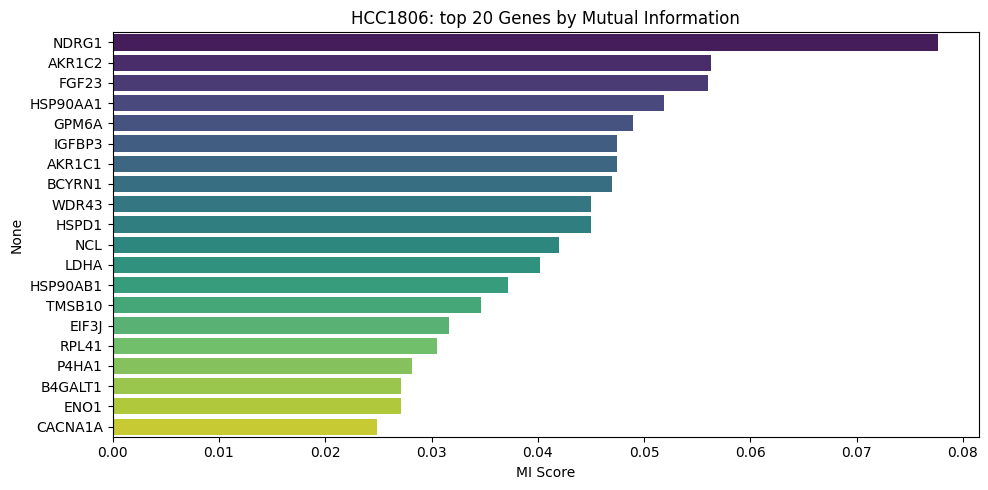

In [11]:
plt.figure(figsize=(10, 5))
sns.barplot(x=mi_scores[top_idx][:20], y=top_genes[:20], palette='viridis')
plt.title('HCC1806: top 20 Genes by Mutual Information')
plt.xlabel('MI Score')
plt.tight_layout()
plt.savefig('../outputs/figures/HCC1806_top20_MI_genes.png', dpi=150)
plt.show()

## 4. Cross-validation

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, x_train_top, y_train, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    print(f'name: {name:25s}  mean={scores.mean():.4f}  std={scores.std():.4f}')

name: Logistic Regression        mean=0.9472  std=0.0021
name: SVM                        mean=0.9541  std=0.0022
name: Random Forest              mean=0.9318  std=0.0024
name: Gradient Boosting          mean=0.9313  std=0.0021


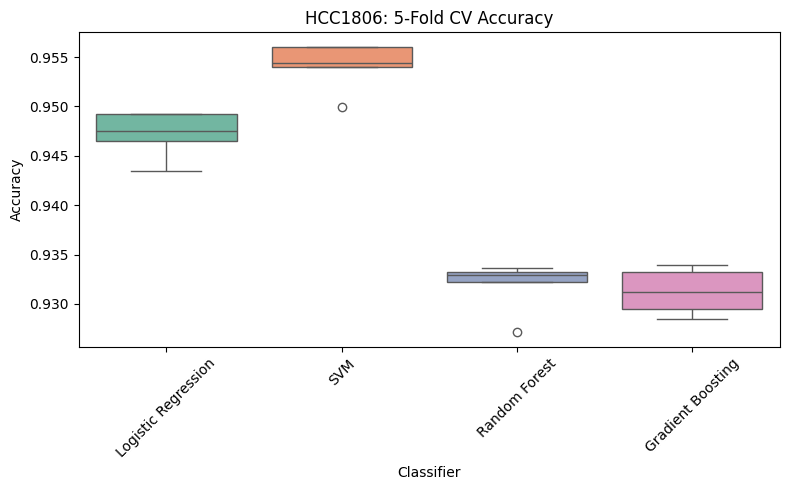

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=pd.DataFrame(cv_results), palette='Set2')
plt.title('HCC1806: 5-Fold CV Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Classifier')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/figures/HCC1806_5foldCV_accuracy.png', dpi=150)
plt.show()

## 5. Train on full train set

also save `.pkl` files

In [14]:
trained_models = {}
for name, model in models.items():
    model.fit(x_train_top, y_train)
    trained_models[name] = model
    path = f'../outputs/models/HCC1806_DropSeq_{name}.pkl'
    with open(path, 'wb') as f:
        pickle.dump(model, f)
    print(f'Saved: {path}')

Saved: ../outputs/models/HCC1806_DropSeq_Logistic Regression.pkl
Saved: ../outputs/models/HCC1806_DropSeq_SVM.pkl
Saved: ../outputs/models/HCC1806_DropSeq_Random Forest.pkl
Saved: ../outputs/models/HCC1806_DropSeq_Gradient Boosting.pkl


## 6. Predict on anonymous test set and save

In [16]:
BEST_MODEL_NAME = 'SVM'

best_model = trained_models[BEST_MODEL_NAME]
preds = best_model.predict(x_test_top)

pred_df = pd.DataFrame({
    'cell': test_raw.index,
    'predicted_label': preds
})

pred_df.to_csv('../outputs/HCC1806_DropSeq_predictions.csv', index=False)
print('Saved: ../outputs/HCC1806_DropSeq_predictions.csv')

Saved: ../outputs/HCC1806_DropSeq_predictions.csv


## 7. Random Forest feature importance

C:\Users\marar\AppData\Local\Temp\ipykernel_30252\3723264076.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance_series.values[:20], y=importance_series.index[:20], palette='magma')


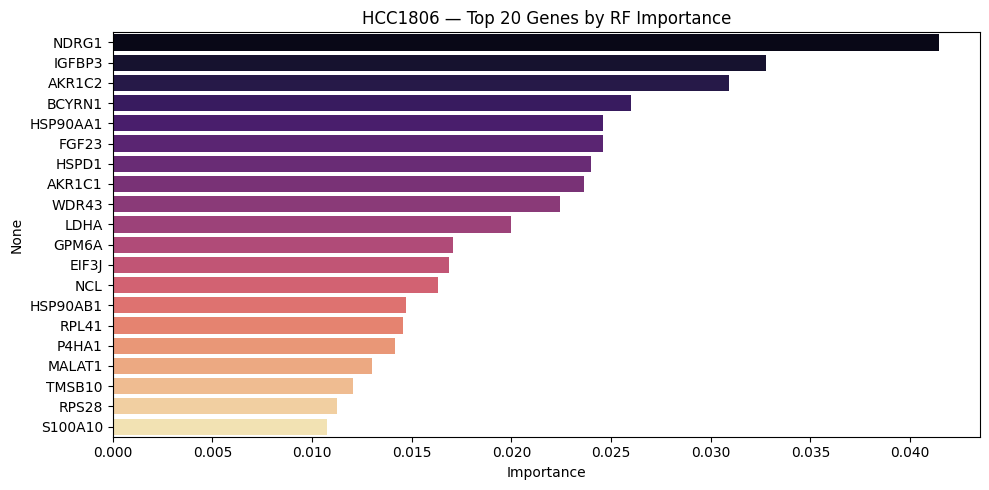

In [18]:
rf = trained_models['Random Forest']
importance_series = pd.Series(rf.feature_importances_, index=top_genes).sort_values(ascending=False)
importance_series.to_csv('../outputs/HCC1806_RF_feature_importance.csv', header=['importance'])

plt.figure(figsize=(10, 5))
sns.barplot(x=importance_series.values[:20], y=importance_series.index[:20], palette='magma')
plt.title('HCC1806 — Top 20 Genes by RF Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../outputs/figures/HCC1806_RF_feature_importance.png', dpi=150)
plt.show() 

## Summary

**Cross-validation results (5-fold, DropSeq HCC1806):**

| Model | Mean Accuracy | Std |
|---|---|---|
| Logistic Regression | 0.9472 | 0.0021 |
| SVM (RBF) | 0.9541 | 0.0022 |
| Random Forest | 0.9318 | 0.0024 |
| Gradient Boosting | 0.9313 | 0.0021 |

**Best model: SVM (RBF)**: selected based on highest mean CV accuracy.

**Saved files:**
- `outputs/models/HCC1806_DropSeq_*.pkl` -> all 4 trained models
- `outputs/HCC1806_DropSeq_predictions.csv` -> predictions on anonymous test set
- `outputs/HCC1806_top_genes.csv` -> top 500 genes by mutual information score
- `outputs/HCC1806_RF_feature_importance.csv` -> Random Forest feature importances (for biological interpretation)
- `outputs/figures/HCC1806_*.png` -> all plots